In [1]:
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

from helpers import (
    avg_frames_from_paths, compute_polynomial_coeffs
)

In [2]:
exp1_path = Path('../../../../Experimental/LabData/contactTesting/20260904')
exp2_path = Path('../../../../Experimental/LabData/contactTesting/20260921')

# 04/09/26
cal1_paths = list(exp1_path.glob('calibration/cal_1*.asm'))
redos = [500, 700, 900]
redo_names = [f'cal_1_{x}N.asm' for x in redos]
cal1_paths = [x for x in cal1_paths if x.name not in redo_names]
def F_from_path(path):
    return int(path.name.split('N')[0].split('_')[-1])
cal1_Fs = [F_from_path(x) for x in cal1_paths]

# 21/09/26
cal2_paths = list(exp2_path.glob('tekscan/calibration/*.asm'))
cal2_Fs = [int(x.name.replace('cal', '').split('.')[0]) for x in cal2_paths]

In [6]:
sensor_id = 3
cal_start_time = 60
avg_window = 5
custom_masks = custom_masks = [[4, -1, 0]] # [[raw_mask_value, j_idx, k_idx], ...]
raw_mask = 0
fit_type = ('poly', False, 3, True) # (type, weight by patch size, degree, zero-intercept)
cal_F_range = (120, 500)

hold_time1 = 180
hold_time2 = 100

fit1_Fs = sorted([x for x in cal1_Fs if x>=cal_F_range[0] and x<=cal_F_range[1]])
cal1_frames = avg_frames_from_paths(
    cal1_paths, fit1_Fs, sensor_id, hold_time1, cal_start_time, avg_window, custom_masks, raw_mask, use_F2=False
    )
fit2_Fs = sorted([x for x in cal2_Fs if x>=cal_F_range[0] and x<=cal_F_range[1]])
#fit2_Fs = np.arange(0, 520, 40)
cal2_frames = avg_frames_from_paths(
    cal2_paths, fit2_Fs, sensor_id, hold_time2, cal_start_time, avg_window, custom_masks, raw_mask, use_F2=True
    )

coeffs1 = compute_polynomial_coeffs(
        cal1_frames, degree=fit_type[2], zero_intercept=fit_type[3], weight_by_patch_size=fit_type[1]
    )
coeffs2 = compute_polynomial_coeffs(
        cal2_frames, degree=fit_type[2], zero_intercept=fit_type[3], weight_by_patch_size=fit_type[1]
    )
coeffs1_4 = compute_polynomial_coeffs(
        cal1_frames, degree=4, zero_intercept=fit_type[3], weight_by_patch_size=fit_type[1]
    )
coeffs2_4 = compute_polynomial_coeffs(
        cal2_frames, degree=4, zero_intercept=fit_type[3], weight_by_patch_size=fit_type[1]
    )

x = np.linspace(0, 255, 1000)
y1 = np.polynomial.polynomial.polyval(x, coeffs1)
y2 = np.polynomial.polynomial.polyval(x, coeffs2)
y1_4 = np.polynomial.polynomial.polyval(x, coeffs1_4)
y2_4 = np.polynomial.polynomial.polyval(x, coeffs2_4)

In [7]:
xlim = (-12.75, 267.75)
ylim = (-0.8, 16.9)

In [8]:
print(sorted(fit2_Fs))
print(coeffs2)

[120, 140, 160, 180, 200, 220, 240, 260, 280, 300, 360, 420, 480]
[ 0.00000000e+00  1.85763860e-02  1.77341517e-04 -1.64342319e-07]


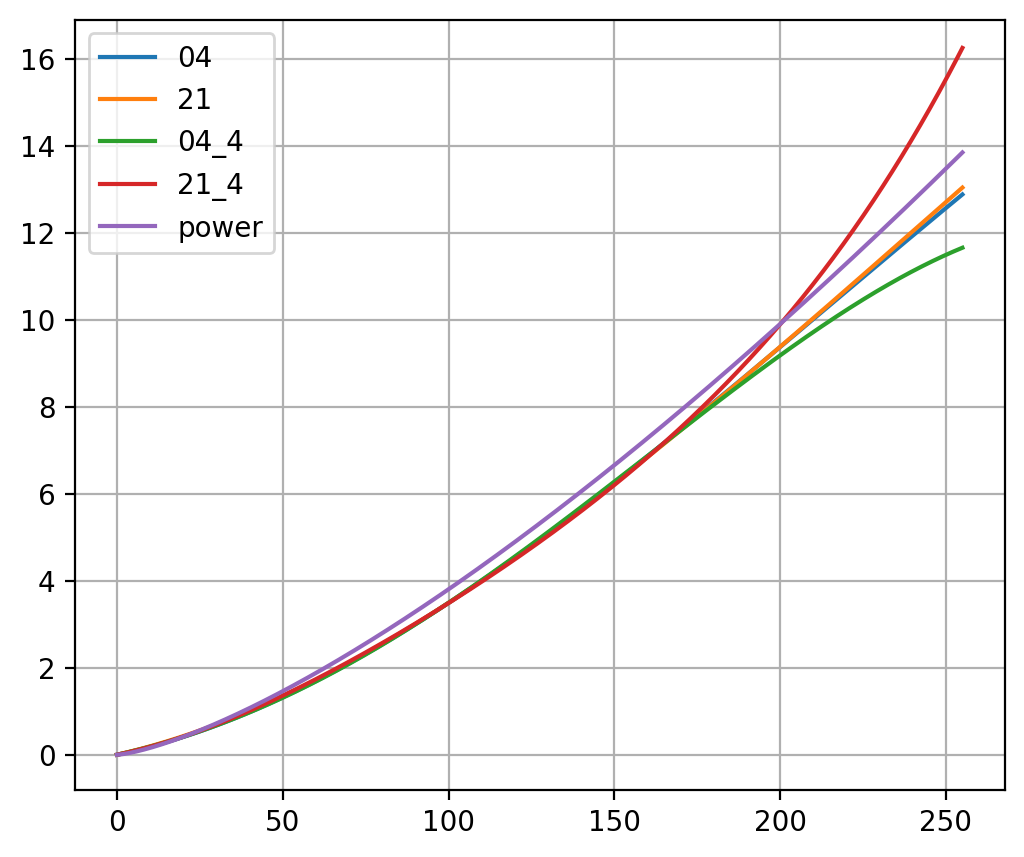

In [ ]:
# (0, 500) - power (10, 200)
# this gives max of 480 for 21 which is 0.8 * 6 (80% of reasonable expected max at 100 N)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')
ax.plot(x, y1_4, label='04_4')
ax.plot(x, y2_4, label='21_4')
a, b = 0.0066, 1.3803
ax.plot(x, a*x**b, label='power')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

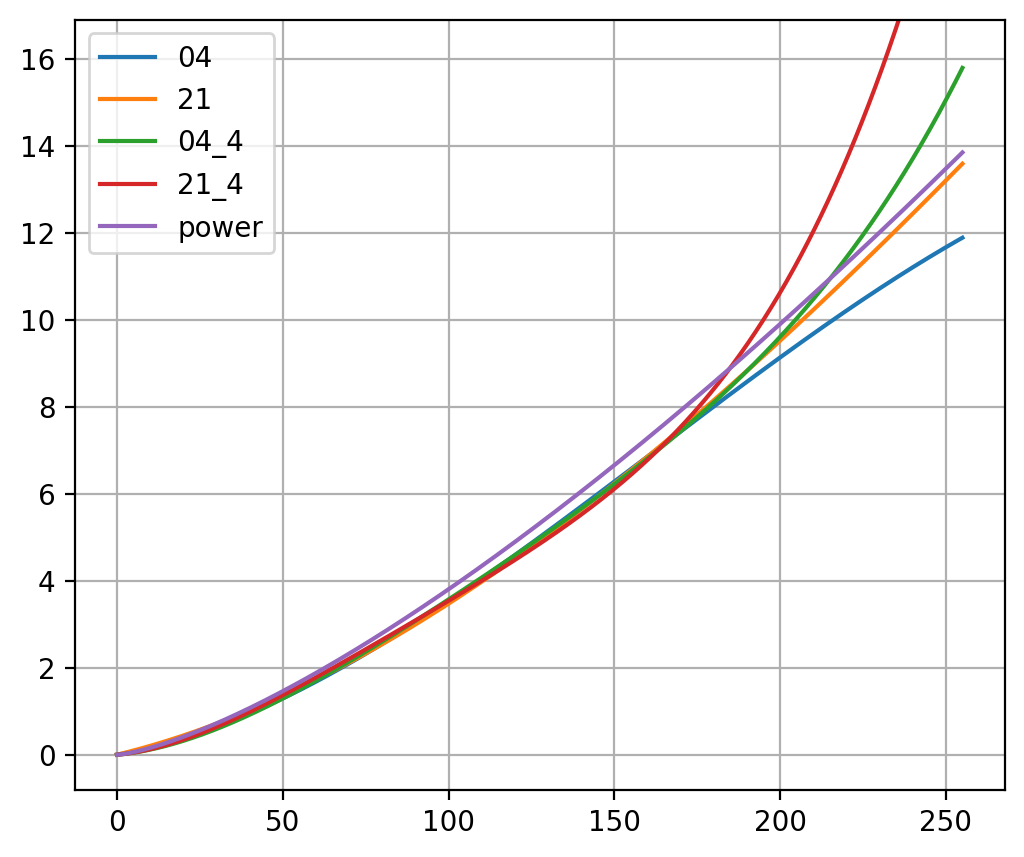

In [63]:
# (120, 500) - power (10, 200)
# this gives max of 480 for 21 which is 0.8 * 6 (80% of reasonable expected max at 100 N)
# 120 is 0.2 * 6 (20%)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')
ax.plot(x, y1_4, label='04_4')
ax.plot(x, y2_4, label='21_4')
a, b = 0.0066, 1.3803
ax.plot(x, a*x**b, label='power')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

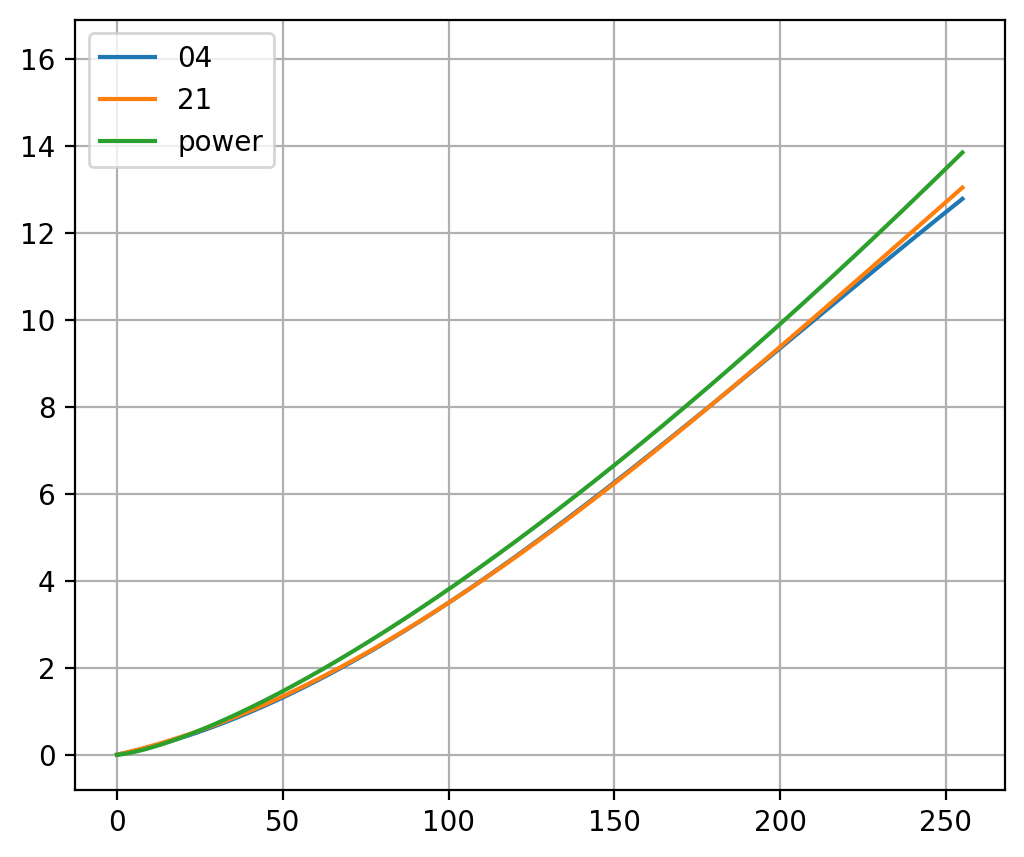

In [57]:
# (20, 500) - power (10, 200)
# this gives max of 480 for 21 which is 0.8 * 6 (80% of reasonable expected max at 100 N)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')
a, b = 0.0066, 1.3803
ax.plot(x, a*x**b, label='power')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

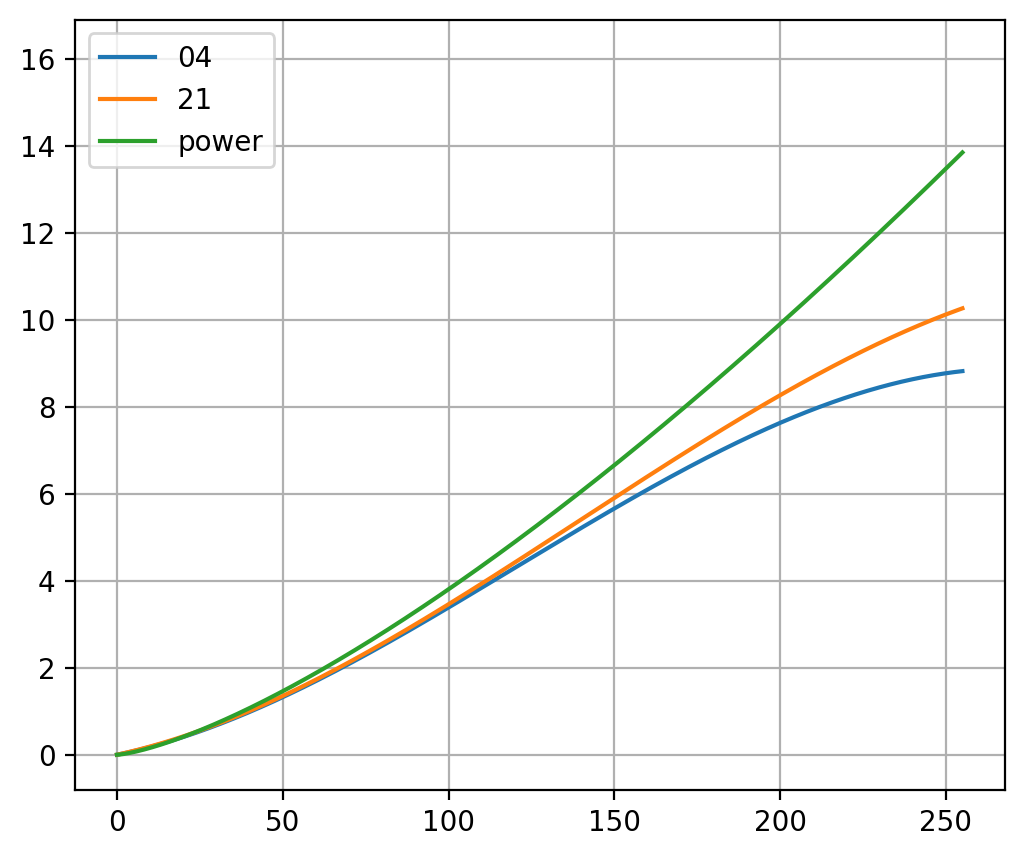

In [ ]:
# (20, 200) - power (10, 200)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')
a, b = 0.0066, 1.3803
ax.plot(x, a*x**b, label='power')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

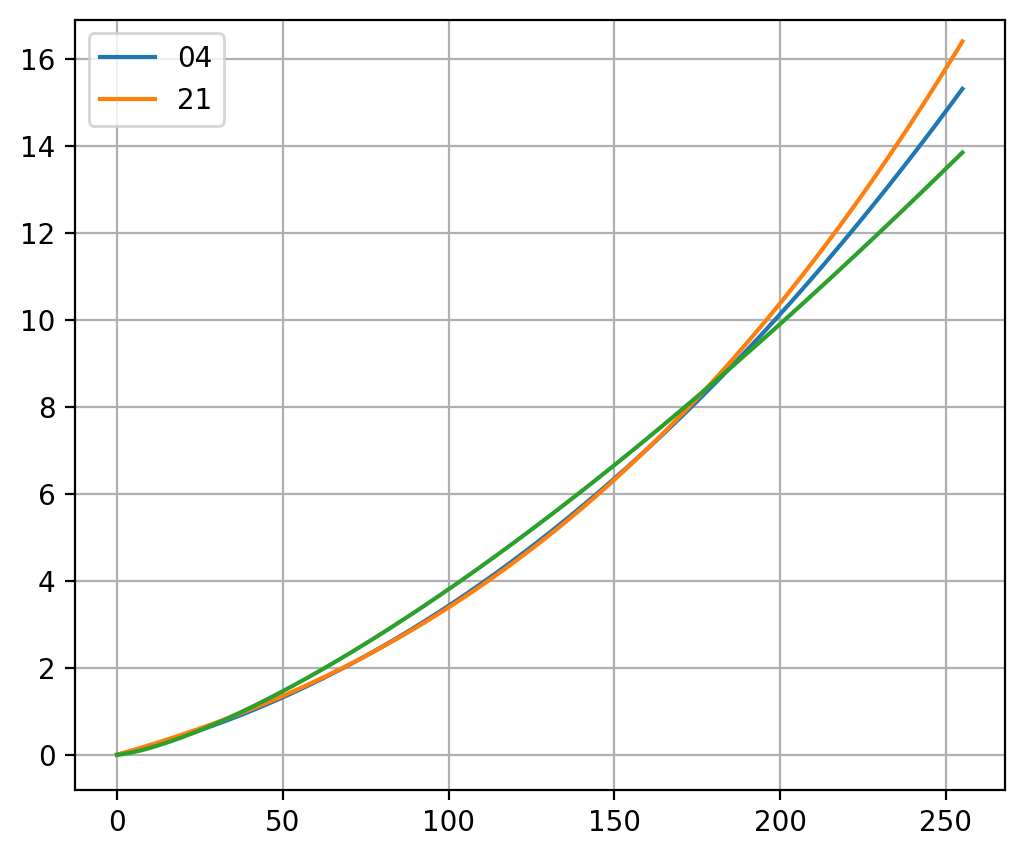

In [ ]:
# (20, 900) and old cal (10, 200)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')
a, b = 0.0066, 1.3803
ax.plot(x, a*x**b)

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

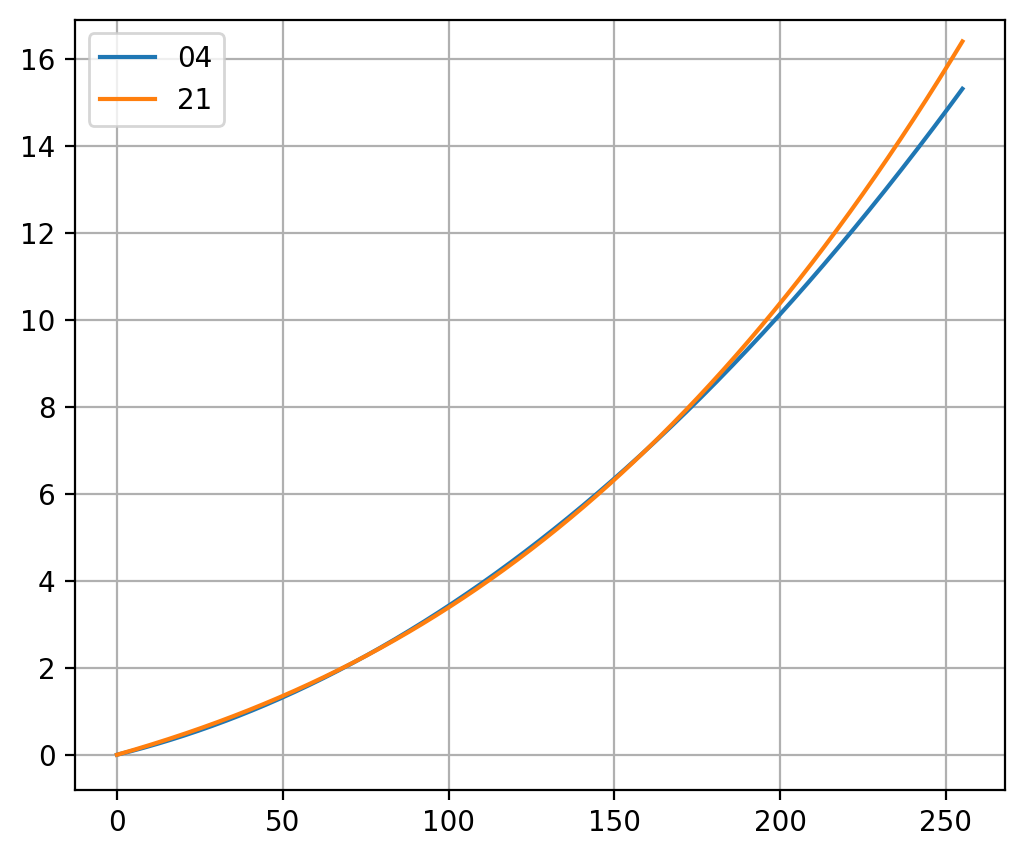

In [ ]:
# (20, 900)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

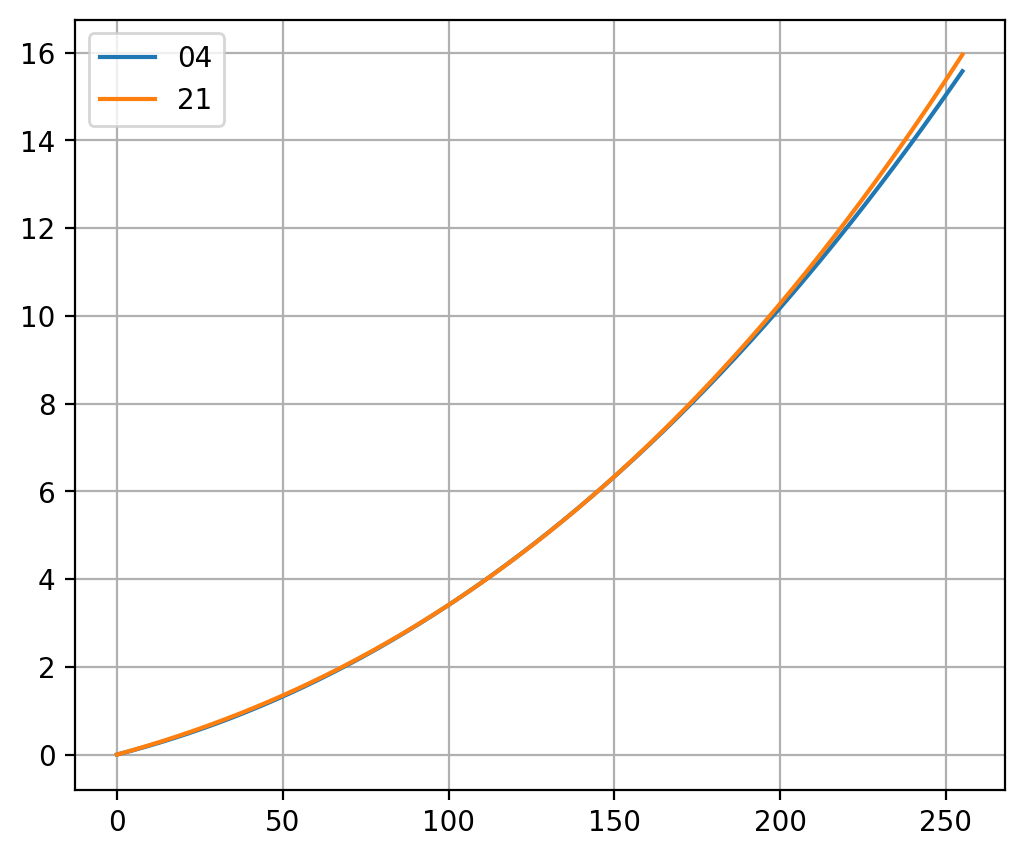

In [ ]:
# (20, 800) - no saturation
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')

ax.set_xlim(xlim)
ax.set_ylim(ylim)
ax.legend()
ax.grid()
plt.show()

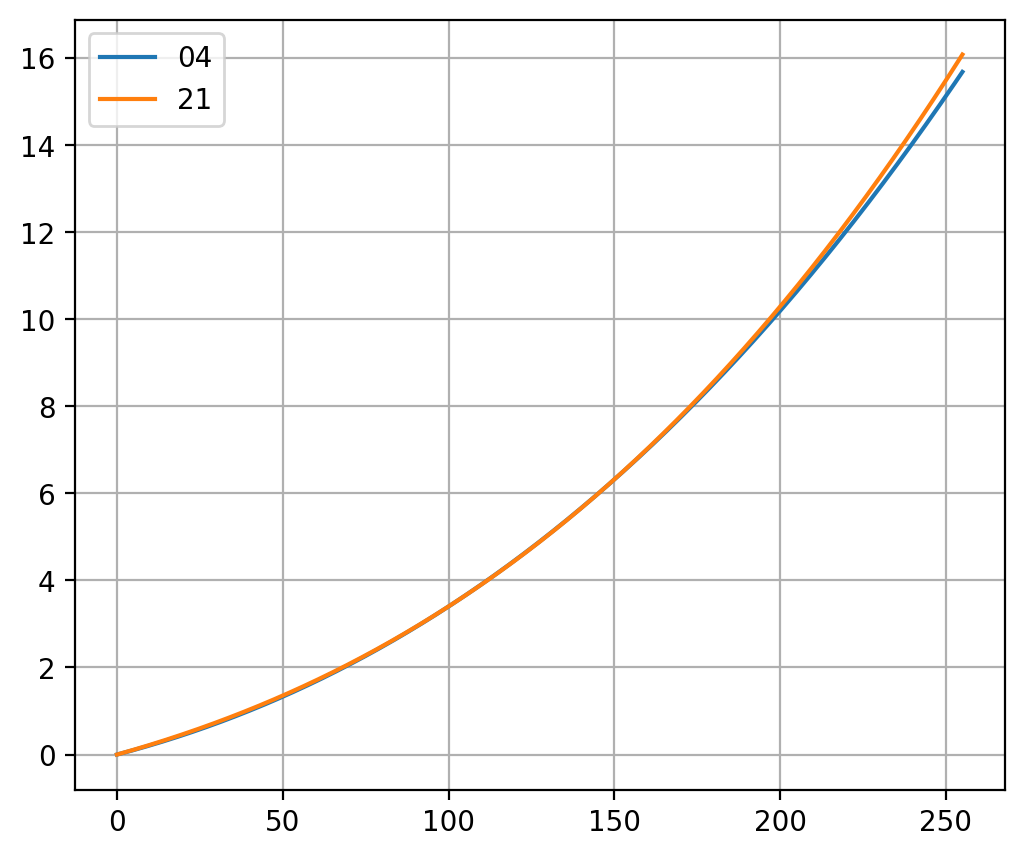

In [21]:
# (60, 800)
nrows, ncols = 1, 1
fig, ax = plt.subplots(nrows, ncols, figsize=(ncols*6,nrows*5), dpi=200)

ax.plot(x, y1, label='04')
ax.plot(x, y2, label='21')

ax.set_xlim(xlim)
ax.set_ylim(ylim)

ax.legend()
ax.grid()
plt.show()